### **Experiment1: Effect of Number of Attention Heads**

* In this experiment, the number of attention heads in the transformer model is varied to study its impact on learning behavior and model performance.

* The baseline configuration uses 4 attention heads. This experiment compares it with two variants: a reduced configuration with 1 head and an increased configuration with 16 heads, while keeping all other parameters constant.

* The objective is to observe how changing the number of attention heads affects training stability, convergence, generalization, and output quality in a small-scale setup.

### **Important Configs**
* to check full config details navigate to configs/exp1_v1_heads.py

* **Model capacity**
    * d_model = 128
    * num_heads = 16
    * num_layers = 4

* **Training core**
    * learning_rate = 3e-4
    * batch_size = 16

### **Experiment Setup for Comparison**

* To simplify this experiment, the model was trained separately with different attention head counts (1, 4(baseline), and 16), and the training metrics for each run were saved as CSV files.
* The following graphs present a side-by-side comparison of these runs to observe the impact of varying the number of attention heads.

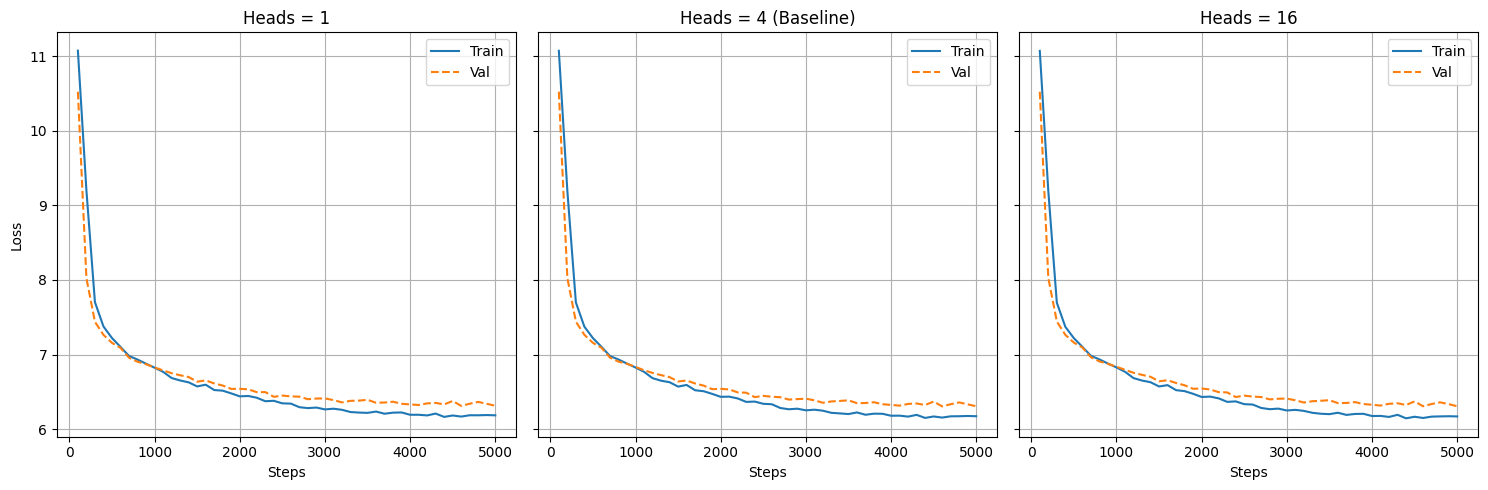

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load all three experiments
df_h1 = pd.read_csv("metrics.csv")
df_h4 = pd.read_csv("../baseline_v1/metrics.csv")   # heads=4
df_h16 = pd.read_csv("metrics_16.csv")

# Create 3 side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# Heads = 1
axes[0].plot(df_h1["step"], df_h1["train_loss"], label="Train")
axes[0].plot(df_h1["step"], df_h1["val_loss"], linestyle="--", label="Val")
axes[0].set_title("Heads = 1")
axes[0].set_xlabel("Steps")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# Heads = 4 (baseline)
axes[1].plot(df_h4["step"], df_h4["train_loss"], label="Train")
axes[1].plot(df_h4["step"], df_h4["val_loss"], linestyle="--", label="Val")
axes[1].set_title("Heads = 4 (Baseline)")
axes[1].set_xlabel("Steps")
axes[1].legend()
axes[1].grid(True) 

# Heads = 16
axes[2].plot(df_h16["step"], df_h16["train_loss"], label="Train")
axes[2].plot(df_h16["step"], df_h16["val_loss"], linestyle="--", label="Val")
axes[2].set_title("Heads = 16")
axes[2].set_xlabel("Steps")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

### **Sample Outputs**

heads = 1

1. Prompt: What is water?
    * Generated: What is water? to being prey a well in its journey . Among that he also they could not do not get around

2. Prompt: The earth is
    * Generated: The earth is also been a steep period of the mind . It had to demonstrate with Nick of several delivery . As

3. Prompt: Once upon a time
    * Generated: Once upon a time of one of specific Dream 's for Homer in music in the film " according and path more writing


heads = 16
1. Prompt: What is water?
    * Generated: What is water? . Following the development of the eye Storm argued was broken dam , the Home less A series was a

2. Prompt: The earth is
    * Generated: The earth is initially they will be used in her . In his wife 's performance , Venuskes from the case

3. Prompt: Once upon a time
    * Generated: Once upon a time @-@ calculation cap @-@ rate . This the industrial @-@ home is his first


### **Observations**

**1. Training Behavior**

- Training curves for heads = 1, 4, and 16 are almost identical
- Loss decreases smoothly in all cases → stable training
- No noticeable difference in convergence speed
- All configurations plateau at similar loss values → similar capacity utilization

**2. Generalization (Train vs Validation)**

- Train and validation loss remain very close across all configurations
- No overfitting observed in any setup
- Generalization behavior is consistent regardless of number of heads

**3. Output Behavior**

- Outputs across heads 1, 4, and 16 are very similar in structure
- All models produce grammatically shaped but semantically weak sentences
- No clear improvement or degradation in coherence with increased or reduced heads
- Slight randomness exists in all outputs, but no significant difference between configurations

### **Conclusion**

* Varying the number of attention heads (1, 4, 16) does not significantly impact training behavior, generalization, or output quality in this small-scale setup.

* This suggests that multi-head attention does not provide a strong advantage for small models trained on limited data, and its benefits are likely to emerge only in larger models or more complex tasks.

### **Steps to run the same experiment again**

**1. Clone the repository**
git clone https://github.com/tulasinnd/decoder-only-transformer-from-scratch.git

**2. Go into the project folder**
cd decoder-only-transformer-from-scratch

**3. Install dependencies**
pip install -r requirements.txt

**4. Run the experiment**
python main.py --config configs.exp1_v1_heads

#### **Experiment Results**

Inside the project folder `decoder-only-transformer-from-scratch`, navigate to: **experiments/exp1_v1_heads/**

**This folder contains the outputs of the experiment:**

* **best_model.pt**  Model with the lowest validation loss (you can use for text generation)

* **resume_checkpoint.pt**  Checkpoint of the model up to the last trained step

* **metrics.csv**  Contains training and validation loss values in CSV format

* **loss_curve.png**  Visual representation of the training curve